## DIPm-TV simulation pipeline

| Scenario | Structure | Tilt range |
|---|---|---|
| **EDX** | Cube + sphere hole + ellipsoid hole | −40 : 5 : +40 (17 proj.) |
| **EELS** | Hollow core-shell nanocube with pore | −70 : 17.5 : +70 (9 proj.) |

In [1]:
import sys
sys.path.insert(0, '../../Src')

from radon import Radon3D
from dipm_tv import CNN3D, run_dipm_tv, preprocess_sinograms

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import rotate as scipy_rotate

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams['image.cmap'] = 'gray'
print(f'Device: {DEVICE}')

# Shared DIPm-TV parameters
NUM_ITER    = 500
LR          = 5e-4
INPUT_DEPTH = 32
NOISE_REG   = 0.01
LAMBDA_TV   = 1e-5

# Full-range reference angles (same for both scenarios)
THETA_REF = np.arange(0, 180, 1)   # 180 projections

def build_net(device=DEVICE):
    return CNN3D(
        nbr=1, input_shape=INPUT_DEPTH,
        down_filters=(16, 32, 64, 128), up_filters=(16, 32, 64, 128),
        skip_filters=( 4,  8, 16,  16),
        down_kernels=(3,)*4, up_kernels=(3,)*4, skip_kernels=(1,)*4,
        up_mode='trilinear', pad_mode='reflect',
    ).to(device)

def _n(arr, sl):
    """Slice a (Z,X,Y) or (1,Z,X,Y) volume and normalise to [0,1]."""
    if torch.is_tensor(arr): arr = arr.detach().cpu().numpy()
    if arr.ndim == 4: arr = arr[0]
    x = arr[sl].astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

def show_quad(gt, sirt_ref, sirt_lim, dipmtv, slices, title):
    """4-row comparison: GT | SIRT ref | SIRT limited | DIPm-TV."""
    rows = [('GT', gt), ('SIRT ref', sirt_ref),
            ('SIRT limited', sirt_lim), ('DIPm-TV', dipmtv)]
    fig, axes = plt.subplots(4, len(slices), figsize=(4.5*len(slices), 4*4))
    for r, (lbl, vol) in enumerate(rows):
        for c, (sl, sl_lbl) in enumerate(slices):
            axes[r, c].imshow(_n(vol, sl))
            axes[r, c].set_title(f'{lbl} — {sl_lbl}', fontsize=8)
            axes[r, c].axis('off')
    plt.suptitle(title, fontsize=10); plt.tight_layout(); plt.show()

Device: cuda


---
## A |  Cube + sphere hole + ellipsoid hole  |  −40 : 5 : +40

### A.1  Build phantom
Volume shape `(Z, X, Y)`: cube spans the full Z range; sphere and ellipsoid sit at **Z = 70**.

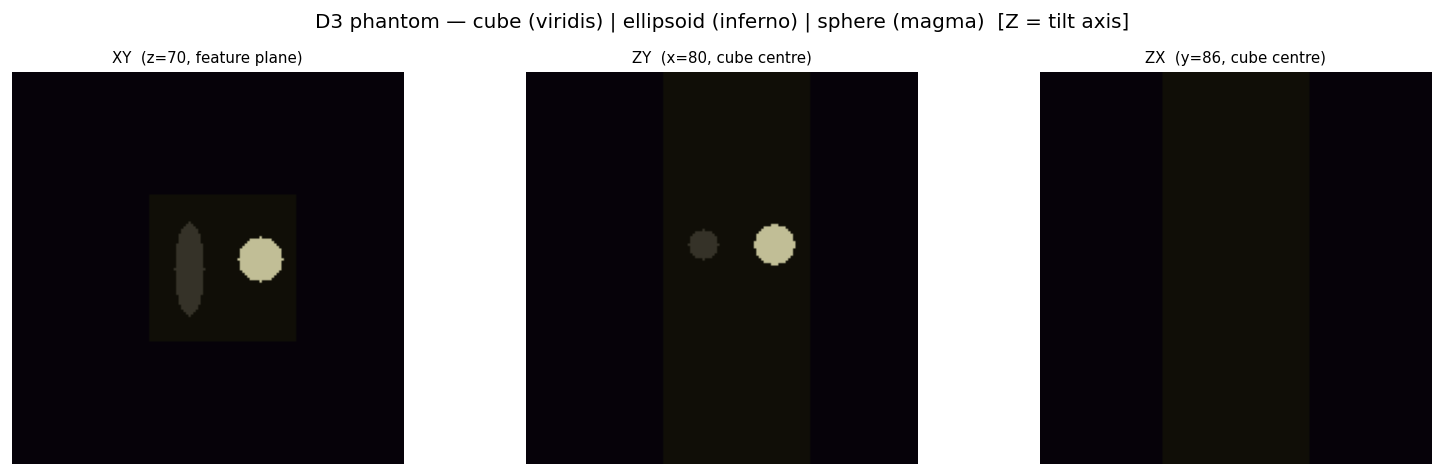

In [2]:
def paint_sphere_center(volume, zc, xc, yc, r, val):
    """Paint sphere in (Z, X, Y) volume."""
    Nz, Nx, Ny = volume.shape
    z0, z1 = max(int(zc-r), 0), min(int(zc+r+1), Nz)
    x0, x1 = max(int(xc-r), 0), min(int(xc+r+1), Nx)
    y0, y1 = max(int(yc-r), 0), min(int(yc+r+1), Ny)
    zz = np.arange(z0, z1)[:, None, None]
    xx = np.arange(x0, x1)[None, :, None]
    yy = np.arange(y0, y1)[None, None, :]
    volume[z0:z1, x0:x1, y0:y1][(zz-zc)**2 + (xx-xc)**2 + (yy-yc)**2 <= r**2] = val

def paint_ellipsoid_center(volume, zc, xc, yc, rz, rx, ry, val=1.0):
    """Paint ellipsoid in (Z, X, Y) volume; semi-axes (rz, rx, ry)."""
    Nz, Nx, Ny = volume.shape
    z0, z1 = max(int(np.floor(zc-rz)), 0), min(int(np.ceil(zc+rz))+1, Nz)
    x0, x1 = max(int(np.floor(xc-rx)), 0), min(int(np.ceil(xc+rx))+1, Nx)
    y0, y1 = max(int(np.floor(yc-ry)), 0), min(int(np.ceil(yc+ry))+1, Ny)
    zz, xx, yy = np.ogrid[z0:z1, x0:x1, y0:y1]
    mask = ((zz-zc)/rz)**2 + ((xx-xc)/rx)**2 + ((yy-yc)/ry)**2 <= 1.0
    volume[z0:z1, x0:x1, y0:y1][mask] = val


NZ_D3 = NX_D3 = NY_D3 = 160   # (Z, X, Y)

# Cube centre in (X, Y)
XC_D3 = NX_D3 // 2           # X centre = 80  (axis 1)
YC_D3 = NY_D3 // 2 + 6       # Y centre = 86  (axis 2)
HALF  = 30                    # cube half-side
Z_FEAT = 70                   # Z position of sphere and ellipsoid

data1_d3 = np.zeros((NZ_D3, NX_D3, NY_D3), dtype=np.float32)  # cube  (main signal)
data2_d3 = np.zeros_like(data1_d3)                             # ellipsoid
data3_d3 = np.zeros_like(data1_d3)                             # sphere

# Cube: full Z extent, centred at (XC_D3, YC_D3) in the XY plane
data1_d3[:, XC_D3-HALF:XC_D3+HALF, YC_D3-HALF:YC_D3+HALF] = 25.0

# Sphere hole at Z=Z_FEAT
paint_sphere_center(data3_d3, Z_FEAT, XC_D3-4,  YC_D3+15, r=9,  val=15.0)
paint_sphere_center(data1_d3, Z_FEAT, XC_D3-4,  YC_D3+15, r=9,  val=0.0)

# Ellipsoid hole at Z=Z_FEAT  (thin in Z and Y, elongated in X)
paint_ellipsoid_center(data2_d3, Z_FEAT, XC_D3, YC_D3-14, rz=6, rx=19, ry=6, val=20.0)
paint_ellipsoid_center(data1_d3, Z_FEAT, XC_D3, YC_D3-14, rz=6, rx=19, ry=6, val=0.0)

# ── Visualise phantom ─────────────────────────────────────────────────
# Key slices for a (Z, X, Y) volume:
#   vol[z, :, :]  → XY plane  (perpendicular to tilt axis)
#   vol[:, x, :]  → ZY plane  (contains tilt axis Z, constant X)
#   vol[:, :, y]  → ZX plane  (contains tilt axis Z, constant Y)
SLICES_D3 = [
    (np.s_[Z_FEAT, :, :],  f'XY  (z={Z_FEAT}, feature plane)'),
    (np.s_[:, XC_D3, :],    f'ZY  (x={XC_D3}, cube centre)'),
    (np.s_[:, :, YC_D3],    f'ZX  (y={YC_D3}, cube centre)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=120)
for ax, (sl, lbl) in zip(axes, SLICES_D3):
    ax.imshow(data1_d3[sl], cmap='viridis', alpha=0.85)
    ax.imshow(data2_d3[sl], cmap='inferno', alpha=0.75)
    ax.imshow(data3_d3[sl], cmap='magma',   alpha=0.75)
    ax.set_title(lbl, fontsize=9); ax.axis('off')
plt.suptitle('D3 phantom — cube (viridis) | ellipsoid (inferno) | sphere (magma)  [Z = tilt axis]')
plt.tight_layout(); plt.show()

### A.2  Reference reconstruction  (0 : 1 : 179, 180 proj.)

In [3]:
# Radon3D: depth = Z (tilt axis = axis 0),  size = X = Y (projection plane)
data1_d3_t = torch.from_numpy(data1_d3).float().to(DEVICE)

rad_ref_d3 = Radon3D(depth=NZ_D3, size=NX_D3, angle=np.deg2rad(THETA_REF), device=DEVICE)
with torch.no_grad():
    sino_ref_d3 = rad_ref_d3(data1_d3_t)   # (Z=160, 180, detector_X=160)

print('SIRT reference D3 (180 proj.)...')
sirt_ref_d3 = rad_ref_d3.backward_sirt_ts(sino_ref_d3, num_iters=100)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (sl, lbl) in zip(axes, SLICES_D3):
    ax.imshow(_n(sirt_ref_d3, sl)); ax.set_title(f'SIRT ref  {lbl}', fontsize=9); ax.axis('off')
plt.suptitle('D3 — SIRT reference (180 proj.)'); plt.tight_layout(); plt.show()

SIRT reference D3 (180 proj.)...


AttributeError: `np.Inf` was removed in the NumPy 2.0 release. Use `np.inf` instead.

### A.3  Limited tilt series  (−40 : 5 : +40)  +  SIRT

In [4]:
# 0-180 convention: physical_angle + 90
THETA_D3 = np.arange(90-40, 90+40+1, 5)   # [50, 55, ..., 130] → 17 proj.
print(f'D3  physical: {THETA_D3[0]-90:.0f} : 5 : {THETA_D3[-1]-90:.0f}   ({len(THETA_D3)} proj.)')

rad_d3 = Radon3D(depth=NZ_D3, size=NX_D3, angle=np.deg2rad(THETA_D3), device=DEVICE)
with torch.no_grad():
    sino_d3 = rad_d3(data1_d3_t)   # (Z=160, 17, detector_X=160)

print('SIRT D3 (17 proj.)...')
sirt_d3 = rad_d3.backward_sirt_ts(sino_d3, num_iters=100)

# Sinogram view: XY sinogram at the feature Z and Z-profile at mid-angle
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(sino_d3[Z_FEAT].cpu().numpy(), aspect='auto',
               extent=[0, NX_D3, THETA_D3[-1]-90, THETA_D3[0]-90])
axes[0].set(title=f'D3 sinogram at Z={Z_FEAT} (feature plane)',
            xlabel='detector X (px)', ylabel='tilt angle (°)')
axes[1].imshow(sino_d3[:, len(THETA_D3)//2, :].cpu().numpy(), aspect='auto')
axes[1].set(title='Z vs detector X at mid-angle',
            xlabel='detector X (px)', ylabel='Z — tilt axis (px)')
plt.tight_layout(); plt.show()

# Quick GT vs SIRT ref vs SIRT limited — XY feature plane
sl_xy = np.s_[Z_FEAT, :, :]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(_n(data1_d3,   sl_xy)); axes[0].set_title('GT')
axes[1].imshow(_n(sirt_ref_d3,sl_xy)); axes[1].set_title('SIRT ref (180 proj.)')
axes[2].imshow(_n(sirt_d3,    sl_xy)); axes[2].set_title('SIRT limited (17 proj.)')
for ax in axes: ax.axis('off')
plt.suptitle(f'D3 — XY plane at Z={Z_FEAT} (elongation artifacts visible here)')
plt.tight_layout(); plt.show()

D3  physical: -40 : 5 : 40   (17 proj.)
SIRT D3 (17 proj.)...


AttributeError: `np.Inf` was removed in the NumPy 2.0 release. Use `np.inf` instead.

### A.4  DIPm-TV

In [ ]:
# Sinogram from Radon3D: (Z, N_ang, detector_X)
# preprocess_sinograms expects (N_ang, Z, detector_X) for single channel
# → transpose axes 0 and 1
sino_d3_np = sino_d3.cpu().numpy().transpose(1, 0, 2)   # (17, Z=160, 160)
sino_d3_t, _, _ = preprocess_sinograms(sino_d3_np, THETA_D3, device=DEVICE)
# → sino_d3_t: (1, Z=160, 17, 160)  — ready for run_dipm_tv

net_d3 = build_net()
print(f'DIPm-TV  D3  ({NUM_ITER} iters)...')
iter_out_d3, loss_d3 = run_dipm_tv(
    net_d3, rad_d3, sino_d3_t,
    sirt_vol=sirt_d3.unsqueeze(0),   # (1, Z, X, Y) for live preview
    num_iter=NUM_ITER, input_depth=INPUT_DEPTH,
    depth=NZ_D3, img_size=NX_D3,
    lr=LR, noise_reg=NOISE_REG, lambda_tv=LAMBDA_TV,
    plot_every=50, plot_slice=Z_FEAT, plot_axis=0,
    save_every=100, device=DEVICE,
)

### A.5  Results  —  GT | SIRT ref | SIRT limited | DIPm-TV

In [ ]:
rec_d3 = iter_out_d3[-1][1]   # (1, Z, X, Y) numpy

show_quad(data1_d3, sirt_ref_d3, sirt_d3, rec_d3, SLICES_D3,
          title='D3 — GT | SIRT ref (180 proj.) | SIRT (17 proj.) | DIPm-TV')

plt.figure(figsize=(5, 3))
plt.semilogy(loss_d3)
plt.title('training loss'); plt.xlabel('iteration'); plt.tight_layout(); plt.show()

---
## B — SIMU MW  |  Core-shell nanocube with pore  |  −70 : 17.5 : +70

### B.1  Build phantom
Volume shape `(Z, X, Y)`. Cubic structure centred at `(Z, X, Y) = (80, 80, 80)`.  
Spherical pore offset `(dZ=0, dX=5, dY=30)` from centre.

In [ ]:
NZ_MW = NX_MW = NY_MW = 160   # (Z, X, Y) — cubic
CZ_MW = CX_MW = CY_MW = NZ_MW // 2   # = 80, centre of the structure

size_shell  = 40
size_core   = 20
pore_radius = 6
dZ_pore, dX_pore, dY_pore = 0, 5, 30   # pore offset from centre in (Z, X, Y)
I_SHELL = 10.0
I_CORE  = 20.0
ROTATIONS = [(5, (0,1)), (7, (1,2)), (13, (0,2))]   # (angle_deg, (axis_a, axis_b))

# Coordinate grids along each axis
gz = np.arange(NZ_MW)[:, None, None]   # axis 0 = Z (tilt axis)
gx = np.arange(NX_MW)[None, :, None]   # axis 1 = X
gy = np.arange(NY_MW)[None, None, :]   # axis 2 = Y

def cube_mask(half, cz, cx, cy):
    return ((np.abs(gz - cz) <= half) &
            (np.abs(gx - cx) <= half) &
            (np.abs(gy - cy) <= half))

mask_outer = cube_mask(size_shell, CZ_MW, CX_MW, CY_MW)
mask_core  = cube_mask(size_core,  CZ_MW, CX_MW, CY_MW)
mask_shell = mask_outer & (~mask_core)

pore_dist  = np.sqrt((gz-(CZ_MW+dZ_pore))**2 +
                     (gx-(CX_MW+dX_pore))**2 +
                     (gy-(CY_MW+dY_pore))**2)
mask_pore  = (pore_dist <= pore_radius) & mask_shell

data1_mw = np.zeros((NZ_MW, NX_MW, NY_MW), dtype=np.float32)   # shell
data1_mw[mask_shell] = I_SHELL
data1_mw[mask_pore]  = 0.0

data2_mw = np.zeros_like(data1_mw)   # core
data2_mw[mask_core] = I_CORE

def rotate_and_rebinarize(vol, thr, high):
    out = vol.copy()
    for ang, ax in ROTATIONS:
        out = scipy_rotate(out, angle=ang, axes=ax, reshape=False, order=1)
    return np.where(out > thr, high, 0.0).astype(np.float32)

data1_mw = rotate_and_rebinarize(data1_mw, thr=I_SHELL*0.5, high=I_SHELL)
data2_mw = rotate_and_rebinarize(data2_mw, thr=I_CORE*0.5,  high=I_CORE)

# Slices: XY at Z=mid (elongation plane), ZY at X=mid, ZX at Y=mid
SLICES_MW = [
    (np.s_[CZ_MW, :, :],  f'XY  (z={CZ_MW}, mid — elongation plane)'),
    (np.s_[:, CX_MW, :],   f'ZY  (x={CX_MW}, cube centre)'),
    (np.s_[:, :, CY_MW],   f'ZX  (y={CY_MW}, cube centre)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=120)
for ax, (sl, lbl) in zip(axes, SLICES_MW):
    ax.imshow(data1_mw[sl], cmap='viridis', alpha=0.85)
    ax.imshow(data2_mw[sl], cmap='inferno', alpha=0.75)
    ax.set_title(lbl, fontsize=9); ax.axis('off')
plt.suptitle('SIMU MW phantom — shell (viridis) + core (inferno)  [Z = tilt axis]')
plt.tight_layout(); plt.show()

### B.2  Reference reconstruction  (0 : 1 : 179, 180 proj.)

In [ ]:
data1_mw_t = torch.from_numpy(data1_mw).float().to(DEVICE)

rad_ref_mw = Radon3D(depth=NZ_MW, size=NX_MW, angle=np.deg2rad(THETA_REF), device=DEVICE)
with torch.no_grad():
    sino_ref_mw = rad_ref_mw(data1_mw_t)   # (Z=160, 180, detector_X=160)

print('SIRT reference SIMU MW (180 proj.)...')
sirt_ref_mw = rad_ref_mw.backward_sirt_ts(sino_ref_mw, num_iters=100)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (sl, lbl) in zip(axes, SLICES_MW):
    ax.imshow(_n(sirt_ref_mw, sl)); ax.set_title(f'SIRT ref  {lbl}', fontsize=9); ax.axis('off')
plt.suptitle('SIMU MW — SIRT reference (180 proj.)'); plt.tight_layout(); plt.show()

### B.3  Limited tilt series  (−70 : 17.5 : +70)  +  SIRT

In [ ]:
THETA_MW = np.arange(90-70, 90+70+1, 17.5)   # [20, 37.5, ..., 160] → 9 proj.
print(f'MW  physical: {THETA_MW[0]-90:.1f} : 17.5 : {THETA_MW[-1]-90:.1f}   ({len(THETA_MW)} proj.)')

rad_mw = Radon3D(depth=NZ_MW, size=NX_MW, angle=np.deg2rad(THETA_MW), device=DEVICE)
with torch.no_grad():
    sino_mw = rad_mw(data1_mw_t)   # (Z=160, 9, detector_X=160)

print('SIRT SIMU MW (9 proj.)...')
sirt_mw = rad_mw.backward_sirt_ts(sino_mw, num_iters=100)

# Sinogram view
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(sino_mw[CZ_MW].cpu().numpy(), aspect='auto',
               extent=[0, NX_MW, THETA_MW[-1]-90, THETA_MW[0]-90])
axes[0].set(title=f'SIMU MW sinogram at Z={CZ_MW} (mid)',
            xlabel='detector X (px)', ylabel='tilt angle (°)')
axes[1].imshow(sino_mw[:, len(THETA_MW)//2, :].cpu().numpy(), aspect='auto')
axes[1].set(title='Z vs detector X at mid-angle',
            xlabel='detector X (px)', ylabel='Z — tilt axis (px)')
plt.tight_layout(); plt.show()

# Quick XY comparison
sl_xy = np.s_[CZ_MW, :, :]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(_n(data1_mw,    sl_xy)); axes[0].set_title('GT')
axes[1].imshow(_n(sirt_ref_mw, sl_xy)); axes[1].set_title('SIRT ref (180 proj.)')
axes[2].imshow(_n(sirt_mw,     sl_xy)); axes[2].set_title('SIRT limited (9 proj.)')
for ax in axes: ax.axis('off')
plt.suptitle(f'SIMU MW — XY plane at Z={CZ_MW} (elongation artifacts visible here)')
plt.tight_layout(); plt.show()

### B.4  DIPm-TV

In [ ]:
# (Z, N_ang, detector_X) → transpose → (N_ang, Z, detector_X) for preprocess_sinograms
sino_mw_np = sino_mw.cpu().numpy().transpose(1, 0, 2)   # (9, Z=160, 160)
sino_mw_t, _, _ = preprocess_sinograms(sino_mw_np, THETA_MW, device=DEVICE)
# → sino_mw_t: (1, Z=160, 9, 160)

net_mw = build_net()
print(f'DIPm-TV  SIMU MW  ({NUM_ITER} iters)...')
iter_out_mw, loss_mw = run_dipm_tv(
    net_mw, rad_mw, sino_mw_t,
    sirt_vol=sirt_mw.unsqueeze(0),   # (1, Z, X, Y)
    num_iter=NUM_ITER, input_depth=INPUT_DEPTH,
    depth=NZ_MW, img_size=NX_MW,
    lr=LR, noise_reg=NOISE_REG, lambda_tv=LAMBDA_TV,
    plot_every=50, plot_slice=CZ_MW, plot_axis=0,
    save_every=100, device=DEVICE,
)

### B.5  Results SIMU MW  —  GT | SIRT ref | SIRT limited | DIPm-TV

In [ ]:
rec_mw = iter_out_mw[-1][1]   # (1, Z, X, Y) numpy

show_quad(data1_mw, sirt_ref_mw, sirt_mw, rec_mw, SLICES_MW,
          title='SIMU MW — GT | SIRT ref (180 proj.) | SIRT (9 proj.) | DIPm-TV')

plt.figure(figsize=(5, 3))
plt.semilogy(loss_mw)
plt.title('SIMU MW training loss'); plt.xlabel('iteration'); plt.tight_layout(); plt.show()